In [3]:
import pandas as pd
import os

# The file found in /content is 'Dataset-df_arabica_clean.csv'
file_path = '/content/Dataset-df_arabica_clean.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f'Successfully loaded: {file_path}')
    display(df.head())
    display(df.info())
else:
    print('Dataset file not found. Please check the file name in /content.')

Successfully loaded: /content/Dataset-df_arabica_clean.csv


,ID,Country of Origin,Lot Number,Altitude,Region,Number of Bags,Bag Weight,In-Country Partner,Harvest Year,Grading Date,...,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration
0,0,Colombia,CQU2022015,1700-1930,"Piendamo,Cauca",1,35 kg,Japan Coffee Exchange,2021 / 2022,"September 21st, 2022",...,10,8.58,0,89.33,11.8,0,0,green,3,"September 21st, 2023"
1,1,Taiwan,"The 2022 Pacific Rim Coffee Summit,T037",1200,Chiayi,1,80 kg,Taiwan Coffee Laboratory 台灣咖啡研究室,2021 / 2022,"November 15th, 2022",...,10,8.50,0,87.58,10.5,0,0,blue-green,0,"November 15th, 2023"
2,2,Laos,"The 2022 Pacific Rim Coffee Summit,LA01",1300,Laos Borofen Plateau,19,25 kg,Taiwan Coffee Laboratory 台灣咖啡研究室,2021 / 2022,"November 15th, 2022",...,10,8.33,0,87.42,10.4,0,0,yellowish,2,"November 15th, 2023"
3,3,Costa Rica,CQU2022017,1900,"Los Santos,Tarrazu",1,22 kg,Japan Coffee Exchange,2022,"September 21st, 2022",...,10,8.25,0,87.17,11.8,0,0,green,0,"September 21st, 2023"
4,4,Colombia,CQU2023002,1850-2100,"Popayan,Cauca",2,24 kg,Japan Coffee Exchange,2022,"March 6th, 2023",...,10,8.25,0,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    207 non-null    int64  
 1   Country of Origin     207 non-null    object 
 2   Lot Number            206 non-null    object 
 3   Altitude              206 non-null    object 
 4   Region                205 non-null    object 
 5   Number of Bags        207 non-null    int64  
 6   Bag Weight            207 non-null    object 
 7   In-Country Partner    207 non-null    object 
 8   Harvest Year          207 non-null    object 
 9   Grading Date          207 non-null    object 
 10  Variety               201 non-null    object 
 11  Status                207 non-null    object 
 12  Processing Method     202 non-null    object 
 13  Aroma                 207 non-null    float64
 14  Flavor                207 non-null    float64
 15  Aftertaste            2

None

### Initial Data Analysis
Now that the data is loaded, I will check for missing values and look at the distribution of the sensory attributes (Aroma, Flavor, etc.) to understand the determinants of the 'Total Cup Points'.

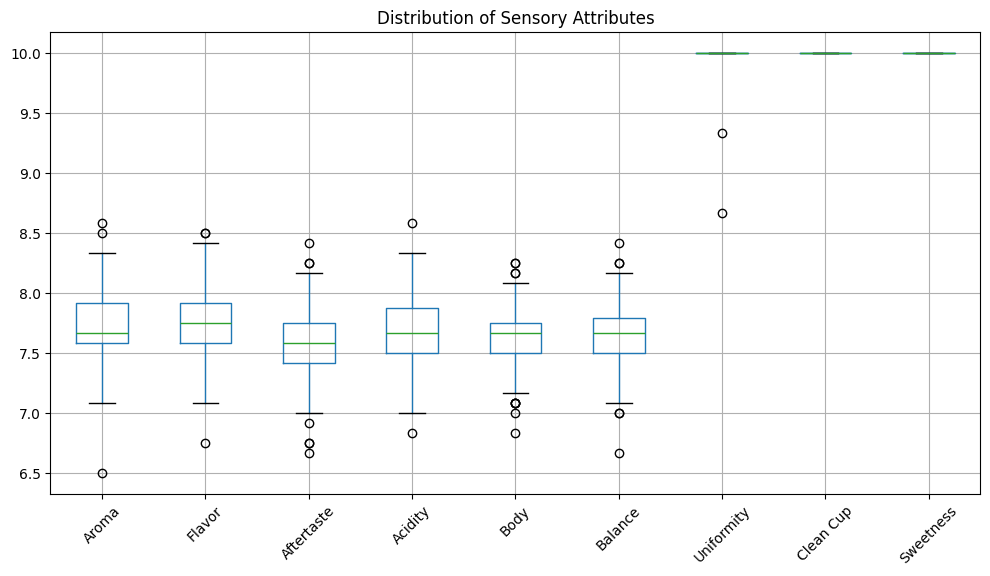

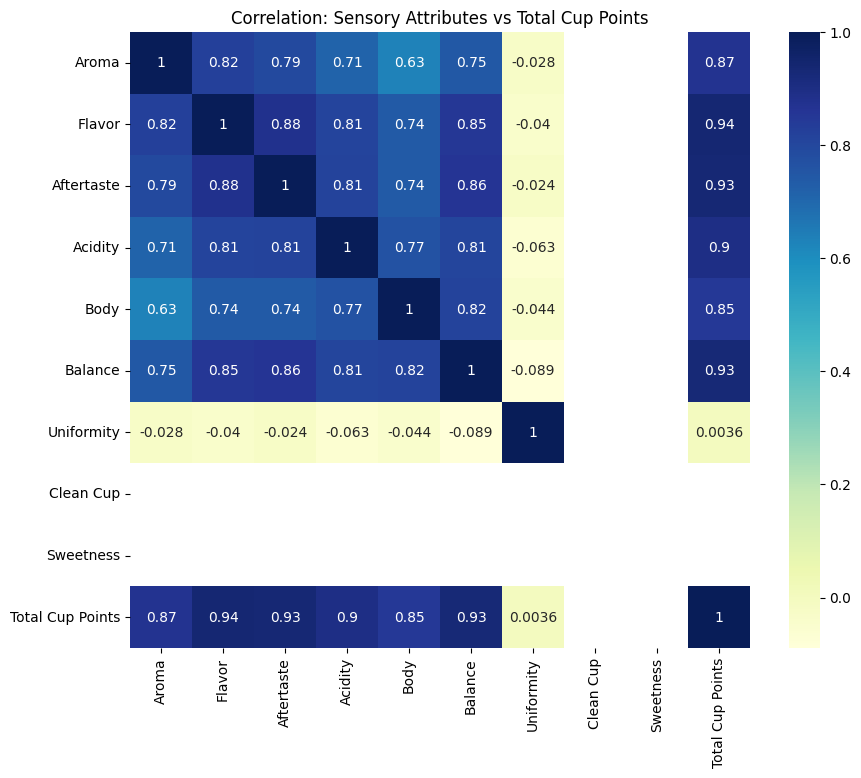

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sensory columns based on CQI documentation
sensory_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness']

# Filter for columns that actually exist in the dataframe
existing_cols = [col for col in sensory_cols if col in df.columns]

if existing_cols:
    # Distribution Analysis
    plt.figure(figsize=(12, 6))
    df[existing_cols].boxplot()
    plt.title('Distribution of Sensory Attributes')
    plt.xticks(rotation=45)
    plt.show()

    # Correlation with Total Cup Points
    target = ['Total Cup Points'] if 'Total Cup Points' in df.columns else []
    if target:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[existing_cols + target].corr(), annot=True, cmap='YlGnBu')
        plt.title('Correlation: Sensory Attributes vs Total Cup Points')
        plt.show()
else:
    print('Sensory columns not found in the dataset. Available columns are:', df.columns.tolist())

### Research Question 2 & 3: Processing, Origin, and Defects
We will now examine how the 'Processing Method' and 'Country of Origin' impact the 'Total Cup Points', and check the frequency of Category One and Category Two defects.

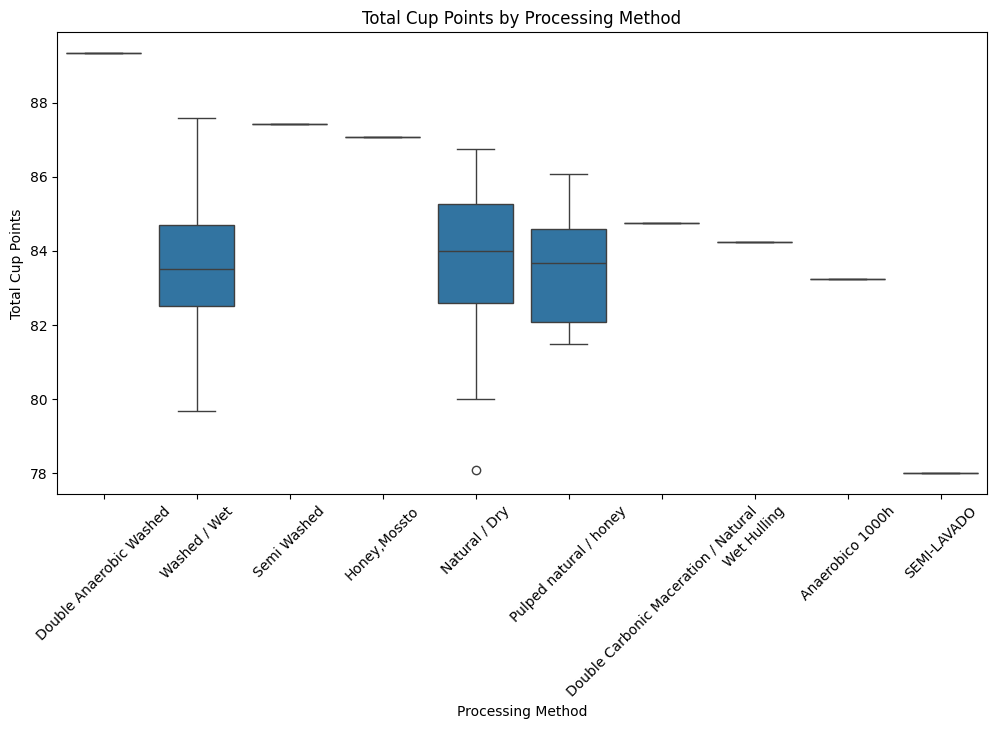

Summary of Defects:


,Category One Defects,Category Two Defects
count,207.000000,207.000000
mean,0.135266,2.251208
std,0.592070,2.950183
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,1.000000
75%,0.000000,3.000000
max,5.000000,16.000000


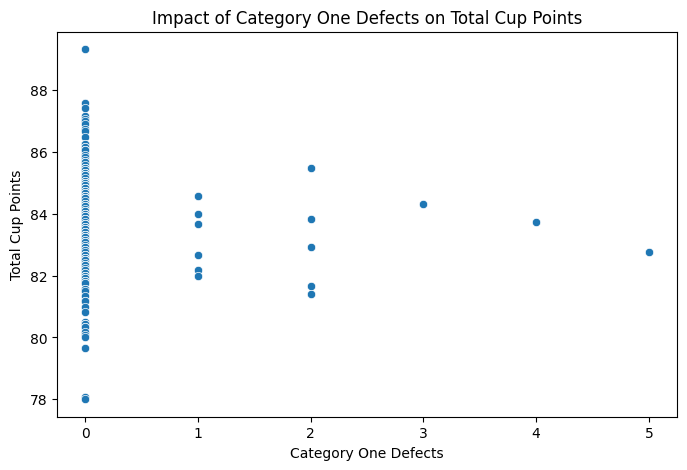

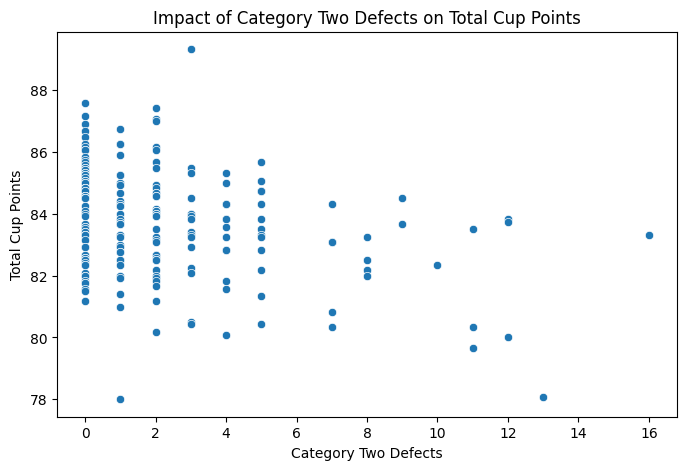

In [5]:
# Analysis of Processing Methods
if 'Processing Method' in df.columns and 'Total Cup Points' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Processing Method', y='Total Cup Points', data=df)
    plt.title('Total Cup Points by Processing Method')
    plt.xticks(rotation=45)
    plt.show()

# Analysis of Defects
defect_cols = ['Category One Defects', 'Category Two Defects']
existing_defects = [col for col in defect_cols if col in df.columns]

if existing_defects:
    print("Summary of Defects:")
    display(df[existing_defects].describe())

    # Impact of defects on Quality
    if 'Total Cup Points' in df.columns:
        for col in existing_defects:
            plt.figure(figsize=(8, 5))
            sns.scatterplot(x=col, y='Total Cup Points', data=df)
            plt.title(f'Impact of {col} on Total Cup Points')
            plt.show()
else:
    print("Defect columns not found.")